## 0. Imports

In [61]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage.morphology import binary_opening, binary_closing, remove_small_objects, disk
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (balanced_accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')


## 1. Load data with LoadHSI (no dark/white correction)

In [62]:
# --- Load cached grain spectra with image-level split ---

import numpy as np
import pandas as pd

CACHE_PATH = "cached_pixel_spectra_image_split_v1.npz"

data = np.load(CACHE_PATH, allow_pickle=True)

X_all_raw = data["X_all_raw"]
y_all = data["y_all"]
image_id_all = data["image_id_all"]
split_all = data["split_all"]
size_all = data["size_all"]
wlens = data["wlens"]
varieties = list(data["varieties"])

wavelengths = wlens

print("X_all_raw shape:", X_all_raw.shape)
print("y_all shape:", y_all.shape)
print("Loaded varieties:", varieties)

print("\nPixels per split:")
print(pd.Series(split_all).value_counts())

print("\nImages per split:")
print(pd.DataFrame({
    "image": image_id_all,
    "split": split_all
}).drop_duplicates().groupby("split").size())

X_all_raw shape: (45000, 180)
y_all shape: (45000,)
Loaded varieties: ['barley', 'corn', 'flax']

Pixels per split:
train    27000
valid     9000
test      9000
Name: count, dtype: int64

Images per split:
split
test      9
train    27
valid     9
dtype: int64


## 2. Preprocessing: mean centering


Mean of centered data: 1.57e-07


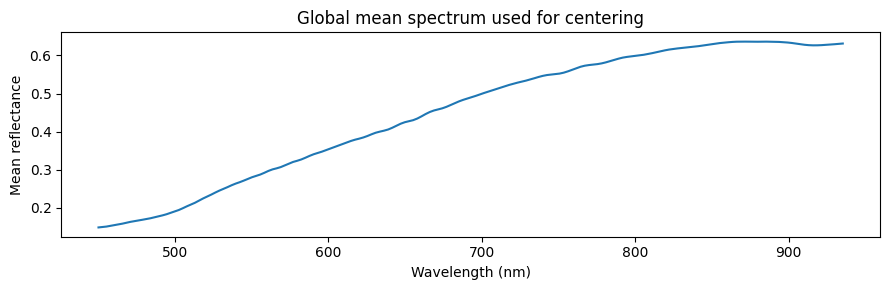

In [63]:
# --- Mean-center data ---

global_mean = X_all_raw.mean(axis=0)

X_all_mc = X_all_raw - global_mean

print("Mean of centered data:", X_all_mc.mean(axis=0).mean().round(10))

plt.figure(figsize=(9, 3))
plt.plot(wavelengths, global_mean)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Mean reflectance")
plt.title("Global mean spectrum used for centering")
plt.tight_layout()
plt.show()

* Mean-centres spectral data by subtracting the global mean spectrum from every pixel spectrum. 
* Mean-centering is important for PCA as it ensures the directions of the max. variance are relative to the origin (the data mean). 
* The plotted global mean spectrum also provides a useful summary of the average reflectance pattern across all sampled grain pixels.

This is primarily for visualization, not the final predictive validation. This is because for that we will be looking into train-set centering preferibally.

## 3. PCA - component selection via variance explained (scree plot)

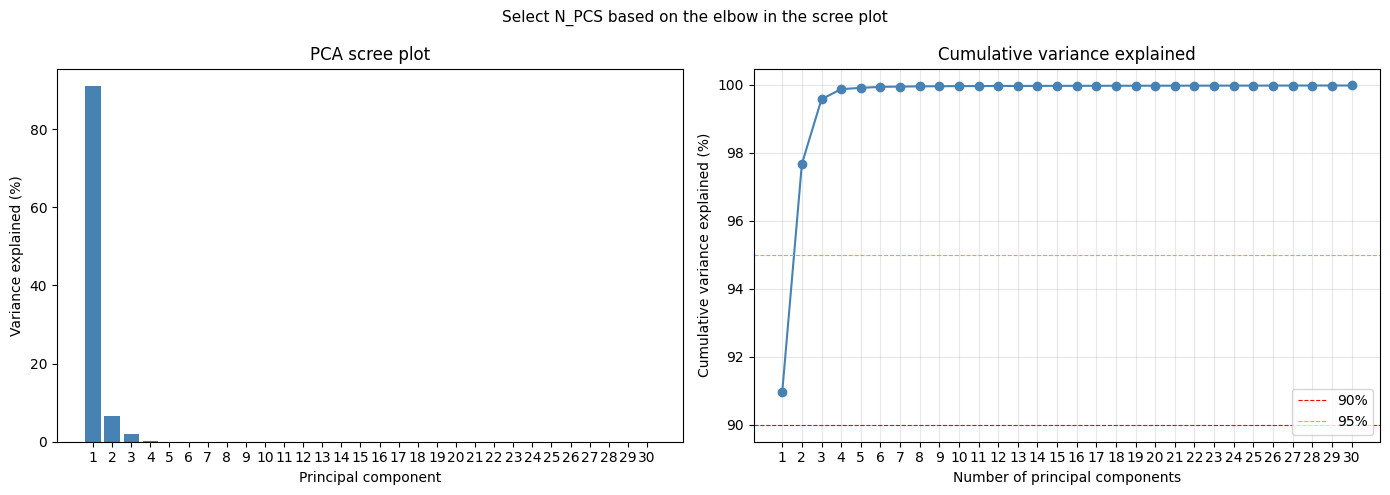

  PC 1: 90.96%  (cumulative: 91.0%)
  PC 2: 6.71%  (cumulative: 97.7%)
  PC 3: 1.90%  (cumulative: 99.6%)
  PC 4: 0.30%  (cumulative: 99.9%)
  PC 5: 0.04%  (cumulative: 99.9%)
  PC 6: 0.03%  (cumulative: 99.9%)
  PC 7: 0.01%  (cumulative: 99.9%)
  PC 8: 0.01%  (cumulative: 100.0%)
  PC 9: 0.00%  (cumulative: 100.0%)
  PC10: 0.00%  (cumulative: 100.0%)
  PC11: 0.00%  (cumulative: 100.0%)
  PC12: 0.00%  (cumulative: 100.0%)
  PC13: 0.00%  (cumulative: 100.0%)
  PC14: 0.00%  (cumulative: 100.0%)
  PC15: 0.00%  (cumulative: 100.0%)


In [64]:
_, S, Vt = np.linalg.svd(X_all_mc, full_matrices=False) # S -> importance of each PC, Vt -> how does each PC look (loadings)

var_exp = (S**2) / (S**2).sum() # singular values -> proportions
cumvar  = np.cumsum(var_exp)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, 31), var_exp[:30] * 100, color='steelblue')
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Variance explained (%)")
axes[0].set_title("PCA scree plot")
axes[0].set_xticks(range(1, 31))

# Cumulative variance
axes[1].plot(range(1, 31), cumvar[:30] * 100, 'o-', color='steelblue')
axes[1].axhline(90, color='red', linestyle='--', linewidth=0.8, label='90%')
axes[1].axhline(95, color='orange', linestyle='--', linewidth=0.8, label='95%')
axes[1].set_xlabel("Number of principal components")
axes[1].set_ylabel("Cumulative variance explained (%)")
axes[1].set_title("Cumulative variance explained")
axes[1].legend()
axes[1].set_xticks(range(1, 31))
axes[1].grid(True, alpha=0.3)

plt.suptitle("Select N_PCS based on the elbow in the scree plot", fontsize=11)
plt.tight_layout()
plt.show()

for i in range(15):
    print(f"  PC{i+1:2d}: {var_exp[i]*100:.2f}%  (cumulative: {cumvar[i]*100:.1f}%)")



* PCA using singular value decomposition and calculates the percentage of variance explained by each principal component. 
* Scree plot shows how much variation is captured by each component
* Cumulative variance plot shows how many components are needed to explain most of the spectral variability.
* Number of retained components is chosen by looking for the point where additional components contribute only small extra amounts of variance.

In [65]:
N_PCS = 3   # set based on visual inspection of the scree plot

## 4. PCA scores and loadings

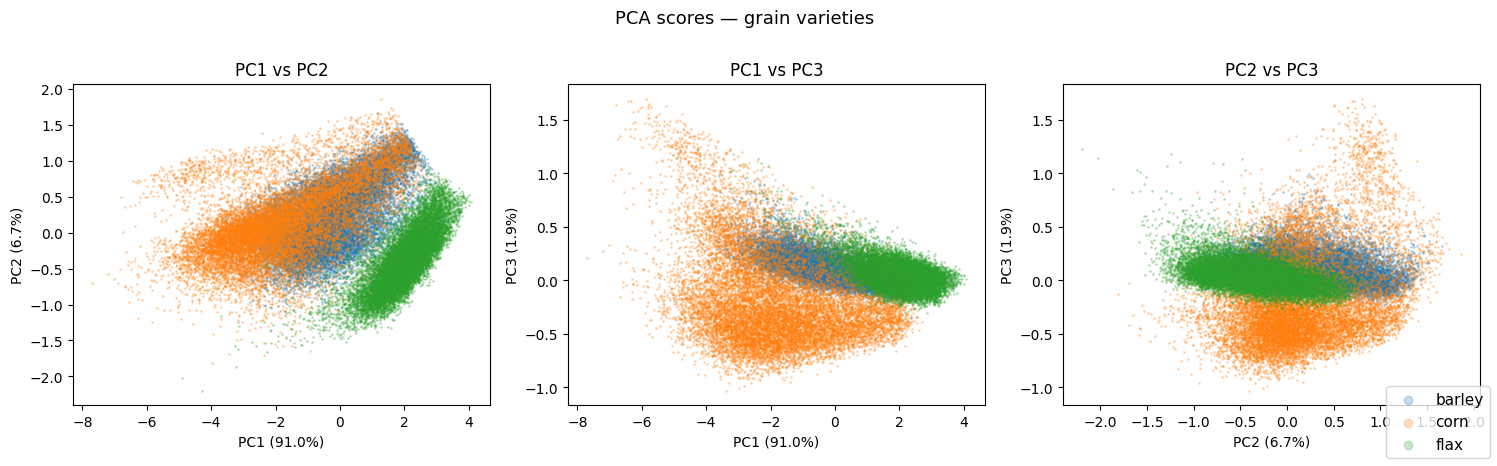

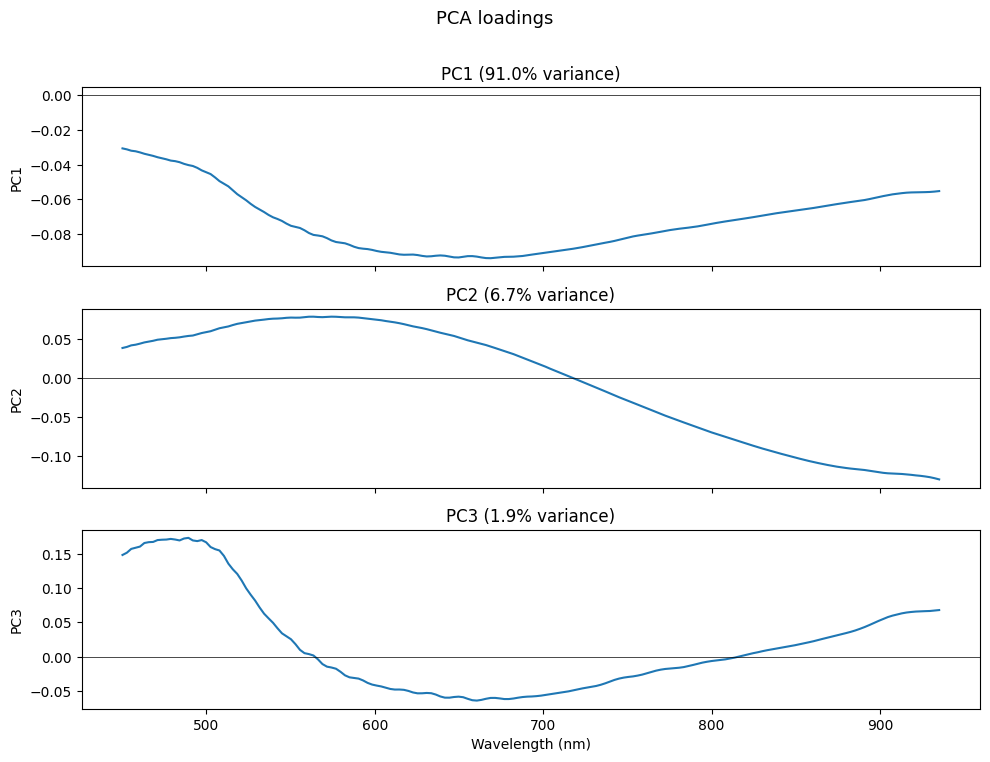

In [66]:
# --- PCA scores and loadings without outlier removal ---

var_explained = (S**2) / (S**2).sum() # how much var each PC explains

loadings = Vt[:N_PCS, :] # take first 3 loading vectors
scores_all = X_all_mc @ loadings.T # project spectra onto PCs (where each sampled pixel lies on PCA space)

pairs = [(i, j) for i in range(N_PCS) for j in range(i + 1, N_PCS)] # all possible PC pairs
ncols = 3
nrows = int(np.ceil(len(pairs) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
axes = np.array(axes).ravel()

for ax, (i, j) in zip(axes, pairs): # plot PCA scores for each class
    for var in varieties:
        mask = y_all == var # select only pixels from that class
        ax.scatter(
            scores_all[mask, i],
            scores_all[mask, j],
            s=1,
            alpha=0.25,
            label=var
        )

    ax.set_xlabel(f"PC{i+1} ({var_explained[i]*100:.1f}%)")
    ax.set_ylabel(f"PC{j+1} ({var_explained[j]*100:.1f}%)")
    ax.set_title(f"PC{i+1} vs PC{j+1}")

for ax in axes[len(pairs):]:
    ax.set_visible(False)

handles, labels_leg = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_leg, markerscale=6, loc="lower right", fontsize=11)

plt.suptitle("PCA scores — grain varieties", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


# --- PCA loadings ---

fig, axes = plt.subplots(N_PCS, 1, figsize=(10, 2.5 * N_PCS), sharex=True)

if N_PCS == 1:
    axes = [axes]

for i, ax in enumerate(axes): # loadings plot
    ax.plot(wavelengths, loadings[i])
    ax.axhline(0, color="k", linewidth=0.5)
    ax.set_ylabel(f"PC{i+1}")
    ax.set_title(f"PC{i+1} ({var_explained[i]*100:.1f}% variance)")

axes[-1].set_xlabel("Wavelength (nm)")

plt.suptitle("PCA loadings", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

* Plots PCA scores and loadings. The score plots show how the sampled pixels are positioned in the reduced PCA space and whether the grain varieties form separate clusters.
* Clear separation between varieties suggests that their spectra differ. 
* Loading plots show which wavelength regions contribute most strongly to each principal component - which features are responsible for variation between samples?
* PC1 - mid 600s wavelengths are the most negative - matter most; PC2 - high 500s most positive; PC3 - high 400s most positive

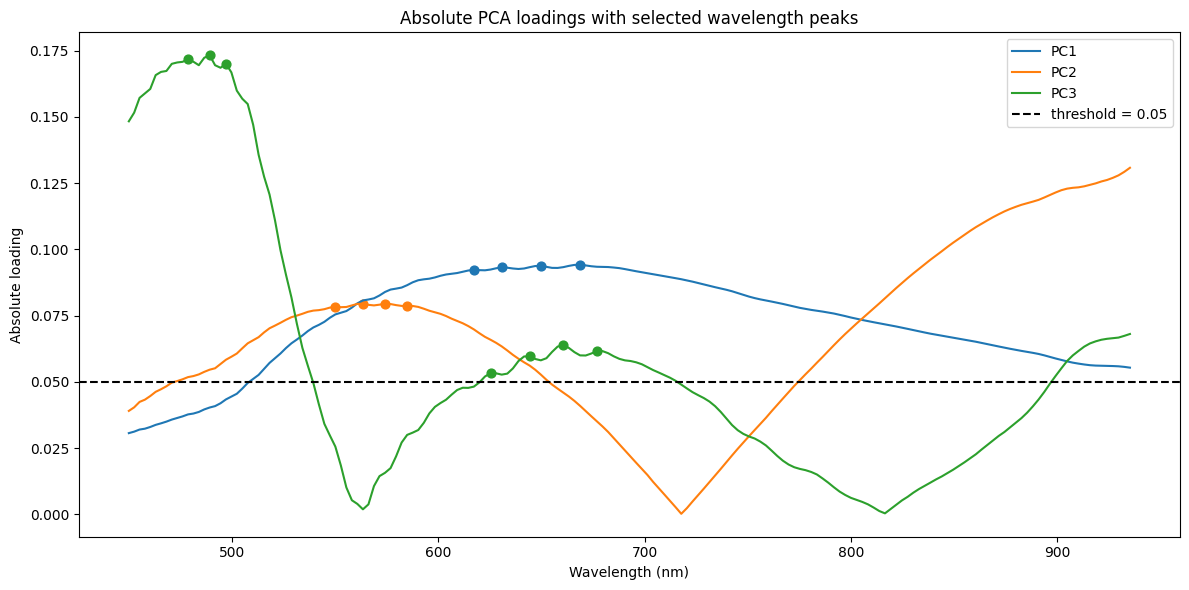

PC1 selected wavelengths: [617.3 630.8 649.8 668.8]
PC2 selected wavelengths: [550.2 563.6 574.3 585. ]
PC3 selected wavelengths: [478.8 489.3 497.2 625.4 644.4 660.6 676.9]


In [67]:
# --- PCA loading-based wavelength selection ---

from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

N_LOADINGS = min(N_PCS, 6)   # similar to plum paper: inspecting first few PCs
loading_threshold = 0.05     # may need adjustment

selected_bands = {}

plt.figure(figsize=(12, 6))

for pc in range(N_LOADINGS):
    abs_loading = np.abs(loadings[pc])

    peaks, properties = find_peaks(
        abs_loading,
        height=loading_threshold
    )

    selected_bands[f"PC{pc+1}"] = wavelengths[peaks]

    plt.plot(
        wavelengths,
        abs_loading,
        label=f"PC{pc+1}"
    )

    plt.scatter(
        wavelengths[peaks],
        abs_loading[peaks],
        s=40
    )

plt.axhline(
    loading_threshold,
    linestyle="--",
    color="black",
    label=f"threshold = {loading_threshold}"
)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Absolute loading")
plt.title("Absolute PCA loadings with selected wavelength peaks")
plt.legend()
plt.tight_layout()
plt.show()

for pc, wl in selected_bands.items():
    print(pc, "selected wavelengths:", np.round(wl, 1))

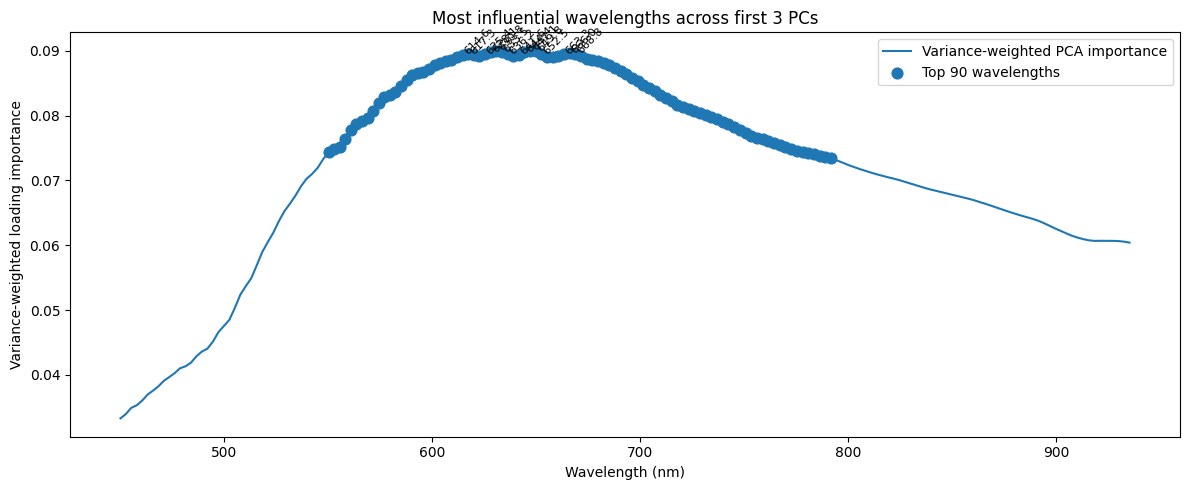

Top selected wavelengths:
[630.8 647.1 649.8 628.1 633.5 644.4 666.  668.8 652.5 636.2 617.3 625.4
 663.3 641.6 614.6 620.  638.9 622.7 671.5 660.6 655.2 611.9 657.9 674.2
 609.2 676.9 606.5 679.6 603.8 682.4 685.1 601.1 687.8 598.4 690.5 595.7
 593.1 693.3 590.4 696.  587.7 698.7 701.4 585.  704.2 706.9 582.3 709.6
 579.6 577.  712.4 715.1 574.3 717.8 720.5 723.3 726.  571.6 728.7 731.5
 734.2 568.9 736.9 566.2 739.7 563.6 742.4 745.2 560.9 747.9 750.6 753.4
 756.1 558.2 758.8 761.6 764.3 767.1 769.8 555.5 772.6 552.9 775.3 778.
 550.2 780.8 783.5 786.3 789.  791.8]
Top selected band indices:
[ 68  74  75  67  69  73  81  82  76  70  63  66  80  72  62  64  71  65
  83  79  77  61  78  84  60  85  59  86  58  87  88  57  89  56  90  55
  54  91  53  92  52  93  94  51  95  96  50  97  49  48  98  99  47 100
 101 102 103  46 104 105 106  45 107  44 108  43 109 110  42 111 112 113
 114  41 115 116 117 118 119  40 120  39 121 122  38 123 124 125 126 127]


In [68]:
# --- Variance-weighted PCA loading importance across PCs ---

# Use all PCs currently retained in the PCA analysis
N_LOADINGS = N_PCS

# Absolute PCA loadings for selected PCs
abs_loadings = np.abs(loadings[:N_LOADINGS, :])

# Use the explained variance of each PC as its weight
explained_weights = var_explained[:N_LOADINGS]

# Weighted importance: PCs explaining more variance contribute more
band_importance = (abs_loadings * explained_weights[:, np.newaxis]).sum(axis=0)

# Rank all bands from most to least important
ranked_band_indices = np.argsort(band_importance)[::-1]

# Select top wavelengths for visualisation
top_k = 90
top_idx = ranked_band_indices[:top_k]
top_wavelengths = wavelengths[top_idx]

plt.figure(figsize=(12, 5))
plt.plot(wavelengths, band_importance, label="Variance-weighted PCA importance")
plt.scatter(
    top_wavelengths,
    band_importance[top_idx],
    s=60,
    label=f"Top {top_k} wavelengths"
)

for wl, val in zip(top_wavelengths[:15], band_importance[top_idx][:15]):
    plt.text(wl, val, f"{wl:.1f}", fontsize=8, rotation=45)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Variance-weighted loading importance")
plt.title(f"Most influential wavelengths across first {N_LOADINGS} PCs")
plt.legend()
plt.tight_layout()
plt.show()

print("Top selected wavelengths:")
print(np.round(top_wavelengths, 1))

print("Top selected band indices:")
print(top_idx)

The PCA score plots show whether grain varieties separate in reduced spectral space. 

When a PC separates one or more varieties, the corresponding loading plot is inspected to identify which wavelengths contribute most strongly to that separation. 

Peaks in the absolute loading values indicate wavelengths that explain a large share of the spectral variation represented by that PC. These wavelengths can then be compared with the mean spectra of the varieties and considered as candidate bands for reduced-band classification or CNN input.

Remember - let's look back at the mean spectra plot from before:

<p align="center">
    <img src="mean_spectra.png" width="800">
</p>

The wavelengths with high PC1 loadings -> in this case [617.3 630.8 649.8 668.8] -> correspond to regions where the mean spectra differ most clearly.

In [69]:
# --- Store PCA-ranked band indices for later PLS-DA / CNN experiments ---

selected_band_indices = ranked_band_indices

print("Total ranked bands:", len(selected_band_indices))
print("Top 10 selected band indices:", selected_band_indices[:10])
print("Top 10 selected wavelengths:", np.round(wavelengths[selected_band_indices[:10]], 1))

Total ranked bands: 180
Top 10 selected band indices: [68 74 75 67 69 73 81 82 76 70]
Top 10 selected wavelengths: [630.8 647.1 649.8 628.1 633.5 644.4 666.  668.8 652.5 636.2]


## 5. PLS-DA — component selection via cross-validation

In [70]:
# --- Encode labels for multi-class PLS-DA ---

from sklearn.preprocessing import LabelBinarizer

lb = LabelBinarizer()

Y_all = lb.fit_transform(y_all)

print("Classes:", lb.classes_)
print("Y_all shape:", Y_all.shape)

Classes: ['barley' 'corn' 'flax']
Y_all shape: (45000, 3)


In [71]:
N_PLSDA = 3   # chosen where curve transitions from meaningful gains to marginal improvement

In [72]:
# --- Image-level train/valid/test split for PLS-DA ---

from sklearn.preprocessing import LabelBinarizer

lb = LabelBinarizer()
Y_all = lb.fit_transform(y_all)

train_mask = split_all == "train"
valid_mask = split_all == "valid"
test_mask  = split_all == "test"

X_train = X_all_raw[train_mask]
Y_train = Y_all[train_mask]
y_train = y_all[train_mask]

X_valid = X_all_raw[valid_mask]
Y_valid = Y_all[valid_mask]
y_valid = y_all[valid_mask]

X_test = X_all_raw[test_mask]
Y_test = Y_all[test_mask]
y_test = y_all[test_mask]

print("Train:", X_train.shape)
print("Valid:", X_valid.shape)
print("Test:", X_test.shape)

print("\nUnique train images:", len(np.unique(image_id_all[train_mask])))
print("Unique valid images:", len(np.unique(image_id_all[valid_mask])))
print("Unique test images:", len(np.unique(image_id_all[test_mask])))

Train: (27000, 180)
Valid: (9000, 180)
Test: (9000, 180)

Unique train images: 27
Unique valid images: 9
Unique test images: 9


Best number of PLS components: 17
Best validation accuracy: 0.9668888888888889


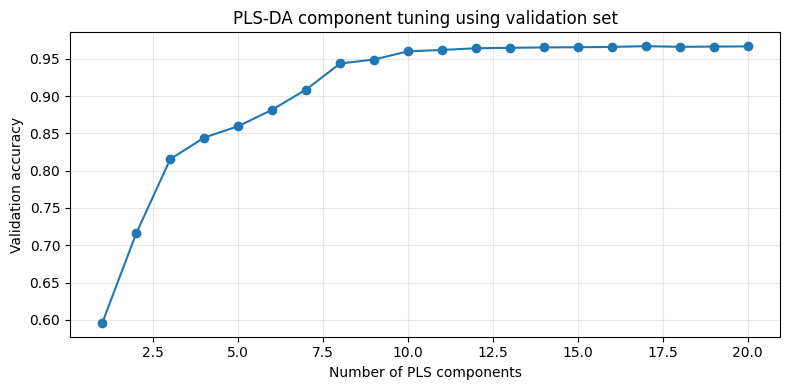

In [73]:
# --- Tune PLS-DA components using validation set ---

from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

component_range = range(1, 21)
valid_scores = []

for n_comp in component_range:

    model = make_pipeline(
        StandardScaler(with_mean=True, with_std=False),
        PLSRegression(n_components=n_comp)
    )

    model.fit(X_train, Y_train)

    Y_valid_scores = model.predict(X_valid)
    y_valid_pred = lb.classes_[np.argmax(Y_valid_scores, axis=1)]

    acc = accuracy_score(y_valid, y_valid_pred)
    valid_scores.append(acc)

best_n = component_range[np.argmax(valid_scores)]

print("Best number of PLS components:", best_n)
print("Best validation accuracy:", max(valid_scores))

plt.figure(figsize=(8, 4))
plt.plot(component_range, valid_scores, marker="o")
plt.xlabel("Number of PLS components")
plt.ylabel("Validation accuracy")
plt.title("PLS-DA component tuning using validation set")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

* Number of PLS-DA components tuned using the validation set. 
* For each candidate number of components, the model is fitted only on the training set and evaluated on the validation set. The component number with the highest validation accuracy is selected, preventing the test set from influencing model selection and keeping the final test evaluation unbiased.

## 10. Final PLS-DA model — evaluation

In [74]:
# --- Compare PLS-DA using all bands vs PCA-selected bands ---

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)
import numpy as np

def evaluate_plsda_band_subset(
    X_train, Y_train, y_train,
    X_valid, Y_valid, y_valid,
    X_test, Y_test, y_test,
    band_indices,
    label
):
    """
    Train and evaluate multi-class PLS-DA using selected wavelength bands.
    """

    X_train_sub = X_train[:, band_indices]
    X_valid_sub = X_valid[:, band_indices]
    X_test_sub  = X_test[:, band_indices]

    max_components = min(15, X_train_sub.shape[1], X_train_sub.shape[0] - 1)

    best_acc = -1
    best_n = None
    best_model = None

    for n_comp in range(1, max_components + 1):

        model = make_pipeline(
            StandardScaler(with_mean=True, with_std=False),
            PLSRegression(n_components=n_comp)
        )

        model.fit(X_train_sub, Y_train)

        Y_valid_scores = model.predict(X_valid_sub)
        y_valid_pred = lb.classes_[np.argmax(Y_valid_scores, axis=1)]

        acc = accuracy_score(y_valid, y_valid_pred)

        if acc > best_acc:
            best_acc = acc
            best_n = n_comp
            best_model = model

    Y_test_scores = best_model.predict(X_test_sub)
    y_test_pred = lb.classes_[np.argmax(Y_test_scores, axis=1)]

    test_acc = accuracy_score(y_test, y_test_pred)

    return {
        "label": label,
        "n_bands": len(band_indices),
        "band_indices": band_indices,
        "wavelengths": wavelengths[band_indices],
        "best_n_components": best_n,
        "val_accuracy": best_acc,
        "test_accuracy": test_acc,
        "test_precision_macro": precision_score(y_test, y_test_pred, average="macro", zero_division=0),
        "test_recall_macro": recall_score(y_test, y_test_pred, average="macro", zero_division=0),
        "test_f1_macro": f1_score(y_test, y_test_pred, average="macro", zero_division=0),
        "confusion_matrix": confusion_matrix(y_test, y_test_pred, labels=lb.classes_),
        "y_test_pred": y_test_pred,
        "model": best_model
    }

In [75]:
# --- Run PLS-DA comparison across different numbers of PCA-ranked bands ---

results_plsda_bands = []

all_band_indices = np.arange(X_train.shape[1])

band_cases = [
    ("PLS-DA: all bands", all_band_indices),
    ("PLS-DA: top 90 PCA bands", selected_band_indices[:90]),
    ("PLS-DA: top 50 PCA bands", selected_band_indices[:50]),
    ("PLS-DA: top 30 PCA bands", selected_band_indices[:30]),
    ("PLS-DA: top 20 PCA bands", selected_band_indices[:20]),
    ("PLS-DA: top 10 PCA bands", selected_band_indices[:10]),
    ("PLS-DA: top 5 PCA bands", selected_band_indices[:5]),
    ("PLS-DA: top 3 PCA bands", selected_band_indices[:3]),
    ("PLS-DA: top 1 PCA band", selected_band_indices[:1]),
]

for label, band_indices in band_cases:
    result = evaluate_plsda_band_subset(
        X_train, Y_train, y_train,
        X_valid, Y_valid, y_valid,
        X_test, Y_test, y_test,
        band_indices,
        label=label
    )
    results_plsda_bands.append(result)

    print(f"\n--- {label} ---")
    print(f"Number of bands: {result['n_bands']}")
    print(f"Best PLS components: {result['best_n_components']}")
    print(f"Validation accuracy: {result['val_accuracy']:.4f}")
    print(f"Test accuracy: {result['test_accuracy']:.4f}")


--- PLS-DA: all bands ---
Number of bands: 180
Best PLS components: 15
Validation accuracy: 0.9654
Test accuracy: 0.9670

--- PLS-DA: top 90 PCA bands ---
Number of bands: 90
Best PLS components: 14
Validation accuracy: 0.8967
Test accuracy: 0.8922

--- PLS-DA: top 50 PCA bands ---
Number of bands: 50
Best PLS components: 9
Validation accuracy: 0.8208
Test accuracy: 0.8119

--- PLS-DA: top 30 PCA bands ---
Number of bands: 30
Best PLS components: 7
Validation accuracy: 0.7687
Test accuracy: 0.7603

--- PLS-DA: top 20 PCA bands ---
Number of bands: 20
Best PLS components: 10
Validation accuracy: 0.7310
Test accuracy: 0.7250

--- PLS-DA: top 10 PCA bands ---
Number of bands: 10
Best PLS components: 9
Validation accuracy: 0.6963
Test accuracy: 0.6911

--- PLS-DA: top 5 PCA bands ---
Number of bands: 5
Best PLS components: 5
Validation accuracy: 0.6522
Test accuracy: 0.6437

--- PLS-DA: top 3 PCA bands ---
Number of bands: 3
Best PLS components: 3
Validation accuracy: 0.6489
Test accuracy

,Model,Number of bands,Best PLS components,Accuracy,Precision,Recall,F1-score
8,PLS-DA: top 1 PCA band,1,1,0.617667,0.411231,0.617667,0.493586
7,PLS-DA: top 3 PCA bands,3,3,0.642556,0.657616,0.642556,0.554959
6,PLS-DA: top 5 PCA bands,5,5,0.643667,0.655468,0.643667,0.556703
5,PLS-DA: top 10 PCA bands,10,9,0.691111,0.724426,0.691111,0.632098
4,PLS-DA: top 20 PCA bands,20,10,0.725000,0.735185,0.725000,0.690357
3,PLS-DA: top 30 PCA bands,30,7,0.760333,0.756502,0.760333,0.744736
2,PLS-DA: top 50 PCA bands,50,9,0.811889,0.807142,0.811889,0.806092
1,PLS-DA: top 90 PCA bands,90,14,0.892222,0.893156,0.892222,0.891616
0,PLS-DA: all bands,180,15,0.967000,0.967318,0.967000,0.966955


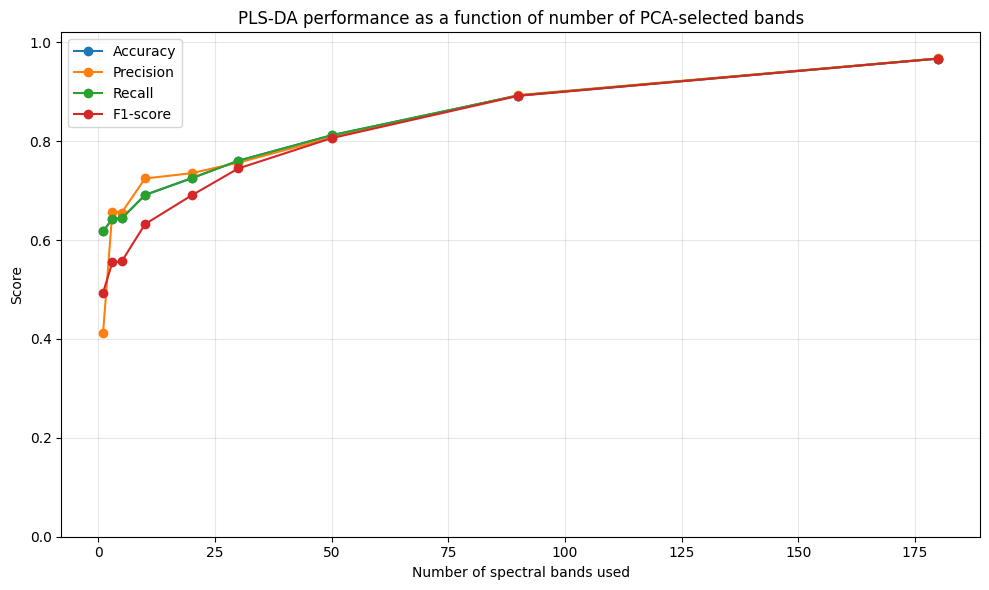

In [76]:
# --- Line plots: classification metrics vs number of bands ---

import pandas as pd
import matplotlib.pyplot as plt

metrics_df = pd.DataFrame([
    {
        "Model": r["label"],
        "Number of bands": r["n_bands"],
        "Best PLS components": r["best_n_components"],
        "Accuracy": r["test_accuracy"],
        "Precision": r["test_precision_macro"],
        "Recall": r["test_recall_macro"],
        "F1-score": r["test_f1_macro"]
    }
    for r in results_plsda_bands
])

metrics_df = metrics_df.sort_values("Number of bands")

display(metrics_df)

plt.figure(figsize=(10, 6))

for metric in ["Accuracy", "Precision", "Recall", "F1-score"]:
    plt.plot(
        metrics_df["Number of bands"],
        metrics_df[metric],
        marker="o",
        label=metric
    )

plt.xlabel("Number of spectral bands used")
plt.ylabel("Score")
plt.title("PLS-DA performance as a function of number of PCA-selected bands")
plt.ylim(0, 1.02)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Plotting the accuracy, precision, recall, and F1-score metrics on a line graph to clearly visualise their progression across different number of bands retained, it seems that retaining the top 30 bands strikes the best balance between a minimal subset of bands (i.e. not keeping too many without significantly increasing performance) and satisfactory results. 


For good measure, let's have a look at the confusion matrices across the different subsets to examine more closely how well the predictions are being made across the different classes.

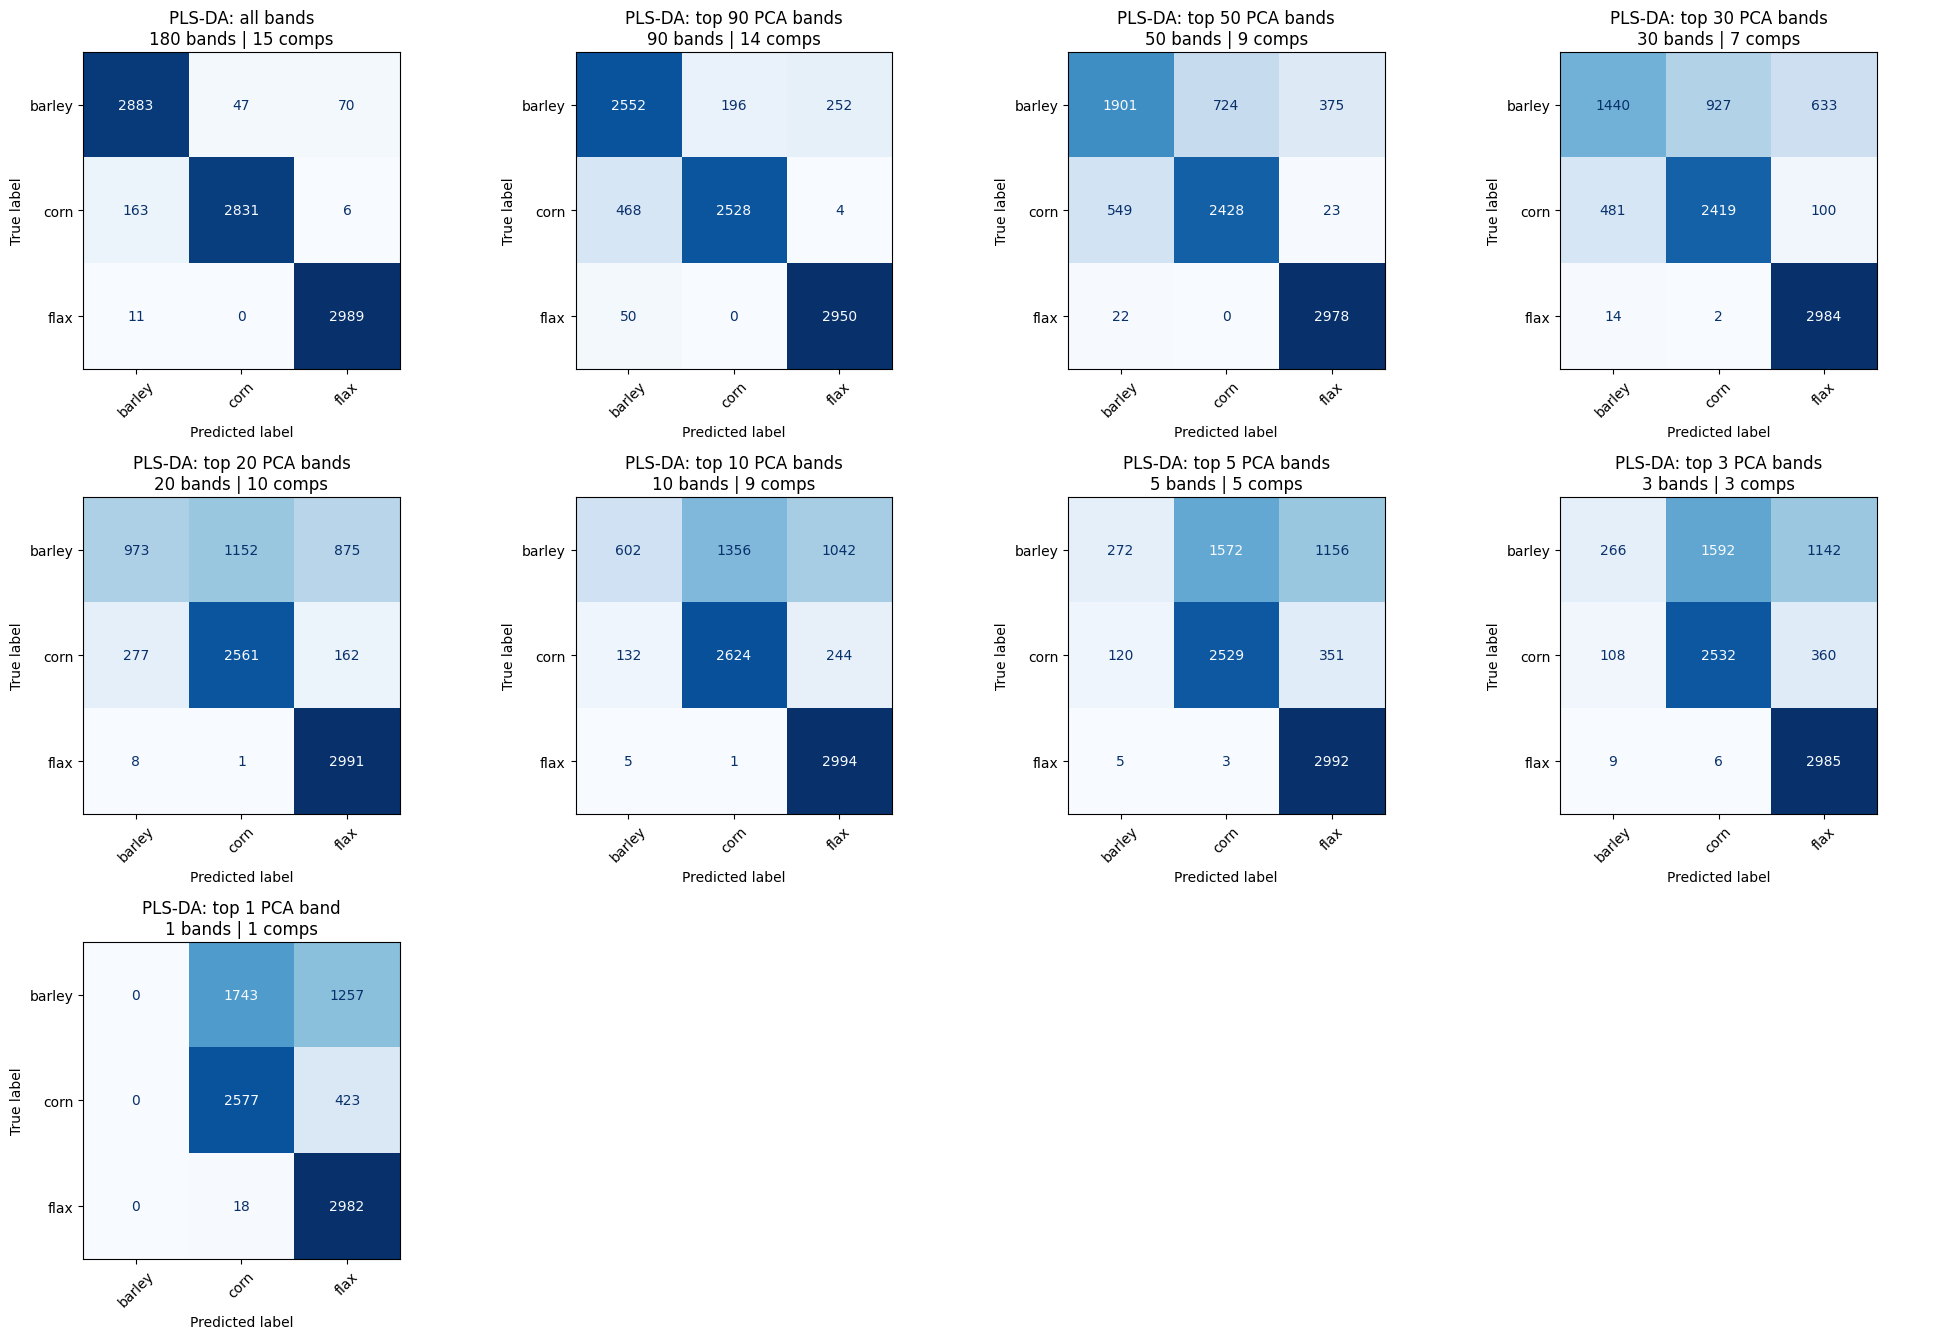

In [77]:
# --- Plot confusion matrices side by side ---

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import math

n_models = len(results_plsda_bands)
max_per_row = 4

n_rows = math.ceil(n_models / max_per_row)
n_cols = min(max_per_row, n_models)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4.5 * n_rows)
)

if n_rows == 1 and n_cols == 1:
    axes = [axes]
elif n_rows == 1:
    axes = axes.flatten()
else:
    axes = axes.flatten()

for ax, result in zip(axes, results_plsda_bands):

    disp = ConfusionMatrixDisplay(
        confusion_matrix=result["confusion_matrix"],
        display_labels=lb.classes_
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
        colorbar=False
    )

    ax.set_title(
        f"{result['label']}\n"
        f"{result['n_bands']} bands | {result['best_n_components']} comps"
    )

    ax.tick_params(axis="x", rotation=45)

for ax in axes[len(results_plsda_bands):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

It seems that the best combination of retaining the least bands possible, whilst still obtaining reliable classification performance is going with the top 30 bands. This represents just a sixth of the full set, yet as the line graph and confusion matrices above show, still achieves respectable performance. Accuracy, precision, recall and F1 score all hover around 84%, whilst the correctly predicted cases still very much outweigh the other cases in the confusion matrix.